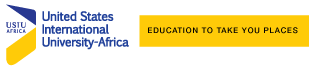

# APT3025 –Applied Machine Learning
# Topic: Data Preprocessing
# Lecturer: Dr. Peter Juma

# WEEK 7: Practical Data Preprocessing
Learning Outcomes
By the end of this course, students will be able to:

1.	Explain data preprocessing
2.	Clean and transform raw data
3.	Prepare datasets for machine learning
4.	Use Python tools for preprocessing


**Step 1: Import Libraries and Load Dataset**

We prepare the environment with libraries liike pandas, numpy, scikit learn, matplotlib and seaborn for data manipulation, numerical operations, visualization and scaling. Load the dataset for preprocessing.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/diabetes.csv')
df.head()

**Step 2: Inspect Data Structure and Check Missing Values**

We understand dataset size, data types and identify any incomplete (missing) data that needs handling.

**df.info():** Prints concise summary including count of non-null entries and data type of each column.

**df.isnull().sum():** Returns the number of missing values per column.

In [ ]:
df.info()
print(df.isnull().sum())

**Step 3: Statistical Summary and Visualizing Outliers**

Get numeric summaries like mean, median, min/max and detect unusual points (outliers). Outliers can skew models if not handled.

**df.describe():** Computes count, mean, std deviation, min/max and quartiles for numerical columns.

**Boxplots:** Visualize spread and detect outliers using matplotlib’s boxplot().

In [ ]:
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

**Step 4: Remove Outliers Using the Interquartile Range (IQR) Method**

Remove extreme values beyond a reasonable range to improve model robustness.

* IQR = Q3 (75th percentile) – Q1 (25th percentile).
* Values below Q1 - 1.5IQR or above Q3 + 1.5IQR are outliers.
* Calculate lower and upper bounds for each column separately.
* Filter data points to keep only those within bounds.

In [ ]:
q1, q3 = np.percentile(df['Insulin'], [25, 75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
clean_df = df[(df['Insulin'] >= lower) & (df['Insulin'] <= upper)]

**Step 5: Correlation Analysis**

Understand relationships between features and the target variable (Outcome). Correlation helps gauge feature importance.

* **df.corr():** Computes pairwise correlation coefficients between columns.
* Heatmap via seaborn visualizes correlation matrix clearly.
* Sorting correlations with **corr['Outcome'].sort_values()** highlights features most correlated with the target.

In [ ]:
corr = df.corr()
plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['Outcome'].sort_values(ascending=False))

**Step 6: Visualize Target Variable Distribution**

Check if target classes (Diabetes vs Not Diabetes) are balanced, affecting model training and evaluation.

* **plt.pie():** Pie chart to display proportion of each class in the target variable 'Outcome'.

In [ ]:
plt.pie(df['Outcome'].value_counts(), labels=[
        'Diabetes', 'Not Diabetes'], autopct='%.f%%', shadow=True)
plt.title('Outcome Proportionality')
plt.show()

**Step 7: Separate Features and Target Variable**

Prepare independent variables (features) and dependent variable (target) separately for modeling.

* **df.drop(columns=[...]):** Drops the target column from features.
* Direct column selection **df['Outcome']** selects target column.

In [ ]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

**Step 8: Feature Scaling: Normalization and Standardization**

Scale features to a common range or distribution, important for many ML algorithms sensitive to feature magnitudes.

1. **Normalization (Min-Max Scaling):** Rescales features between 0 and 1. Good for algorithms like k-NN and neural networks.

* **Class:** MinMaxScaler from sklearn.
* **.fit_transform():** Learns min/max from data and applies scaling.

In [ ]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print(X_normalized[:5])

2. **Standardization:** Transforms features to have mean = 0 and standard deviation = 1, useful for normally distributed features.

* **Class:** StandardScaler from sklearn.

In [ ]:
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
print(X_standardized[:5])